# Challenge: Edit MNIST challenge images to be correctly predicted

Goal: Edit the images placed in `data/MNIST/challenge` so that the provided model predicts the correct label while keeping more than 60% of the original pixels unchanged.

Description: You are given a pre-trained `SmallCNN` model and a small set of challenge images. Your task is to minimally modify these images so the model classifies them correctly. This exercise encourages you to: 
- Explore the sample dataset in `data/MNIST/sample` to understand variation and typical inputs.
- Use explainable AI (XAI) techniques (saliency maps, Grad-CAM, Integrated Gradients, occlusion, etc.) to discover what parts of the image the model relies on.
- Propose minimal edits (pixel changes, small masks, subtle color shifts) that change model prediction while preserving at least 60% of the original pixels.

Deliverables: For each edited image, save the modified image to `data/MNIST/challenge/edited/` alongside a short report (less than 2 pages) describing the XAI insights you used and the percentage of pixels preserved. For ease of use, you have the images already in that folder and you can directly work on them. You are allowed to use any external program you want to modify the image (i.e., paint, photoshop, figma, ...).

The practice can be done by more than 1 person. Final grade would depend on the number of images correctly edited (n_images_correct) with their corresponding report and number of persons working together (n_persons) following the next formula:
$$grade = 2,5 \times n\_images\_correct - 2,5 * (n\_persons - 1)$$


In [1]:
# Imports and device
import torch
import torch.nn as nn
from torchvision import transforms
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

c:\Users\jga20\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Device: cuda


In [2]:
# SmallCNN definition (must match the trained model architecture)
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 12, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(12*7*7, 12)
        self.fc2 = nn.Linear(12, num_classes)

    def forward(self, x):
        x = self.pool(torch.nn.functional.relu(self.conv1(x)))  # 14x14
        x = self.pool(x)                      # 7x7
        x = x.view(x.size(0), -1)
        x = self.dropout(torch.nn.functional.relu(self.fc1(x)))
        return self.fc2(x)

# convenience transform
to_tensor = transforms.ToTensor()
to_pil = transforms.ToPILImage()

In [3]:
models_dir = Path('../models')
model_name = models_dir / 'small_cnn.pth'
model = torch.load(model_name, weights_only=False)
model.to(device) 
model.eval()

SmallCNN(
  (conv1): Conv2d(3, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=588, out_features=12, bias=True)
  (fc2): Linear(in_features=12, out_features=10, bias=True)
)

0_label5.png: Pred: 1, Label: 5
1_label3.png: Pred: 1, Label: 3
2_label3.png: Pred: 1, Label: 3
3_label7.png: Pred: 3, Label: 7
4_label2.png: Pred: 6, Label: 2


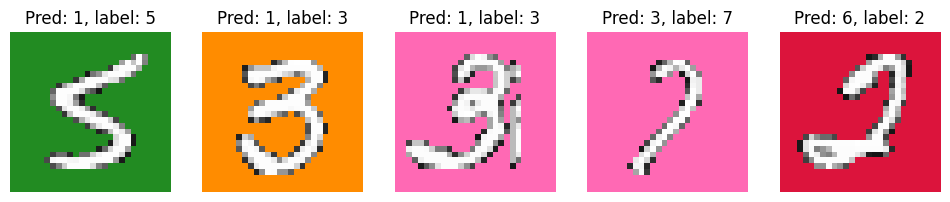

In [4]:
# Load the images in data/MNIST/challenge/ and plot them. Label of the image is the last character of the filename.
challenge_dir = Path('../data/MNIST/challenge')
image_files = list(challenge_dir.glob('*.png'))
fig, axes = plt.subplots(1, len(image_files), figsize=(12,4))
for ax, img_file in zip(axes, image_files):
    img = to_tensor(Image.open(img_file)).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img)
        pred = output.argmax(dim=1).item()
    ax.imshow(to_pil(img.squeeze().cpu()))
    ax.set_title(f'Pred: {pred}, label: {img_file.stem[-1]}')
    ax.axis('off')
    print(f'{img_file.name}: Pred: {pred}, Label: {img_file.stem[-1]}')
plt.show()

---
### Any code you want to add, put it below this markdown cell

0_label5.png: Pred=1, Label=5


C:\Users\jga20\AppData\Local\Temp\ipykernel_20112\3048036160.py:31: RuntimeWarning: invalid value encountered in divide
  saliency /= saliency.max()


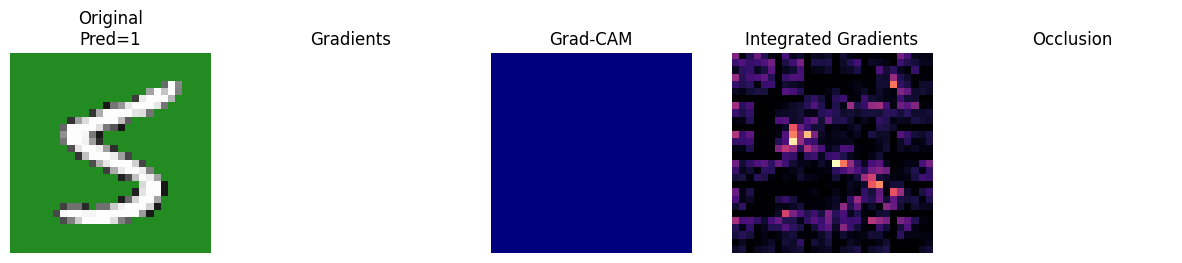

1_label3.png: Pred=1, Label=3


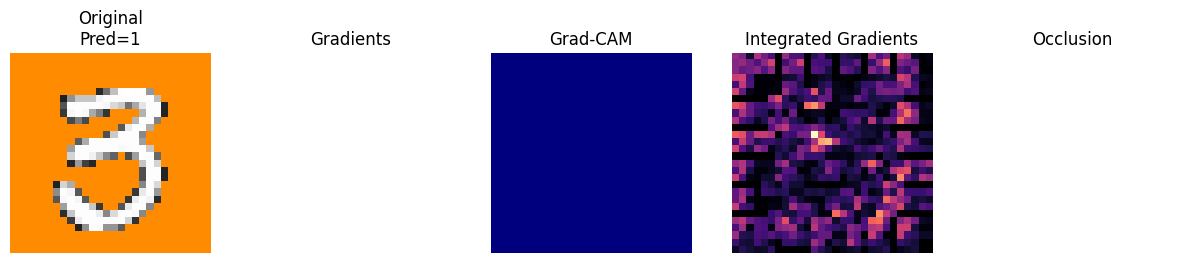

2_label3.png: Pred=1, Label=3


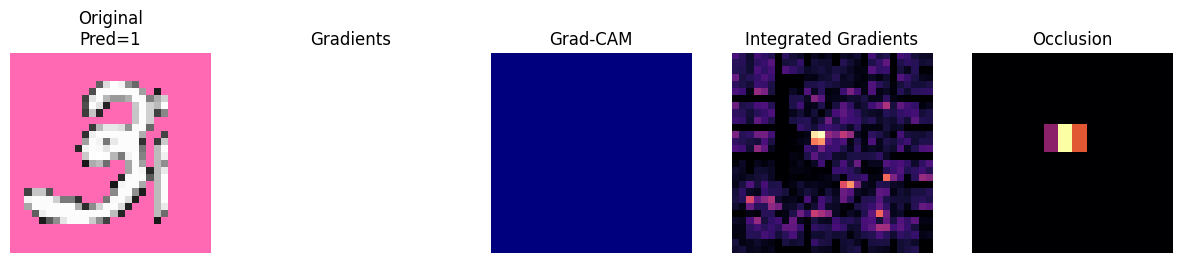

3_label7.png: Pred=3, Label=7


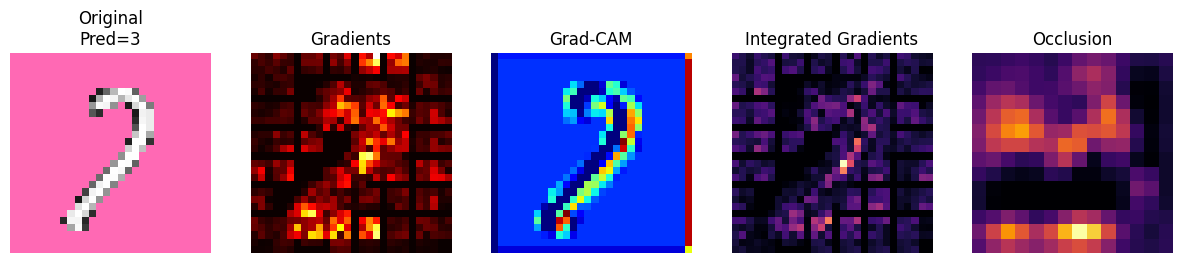

4_label2.png: Pred=6, Label=2


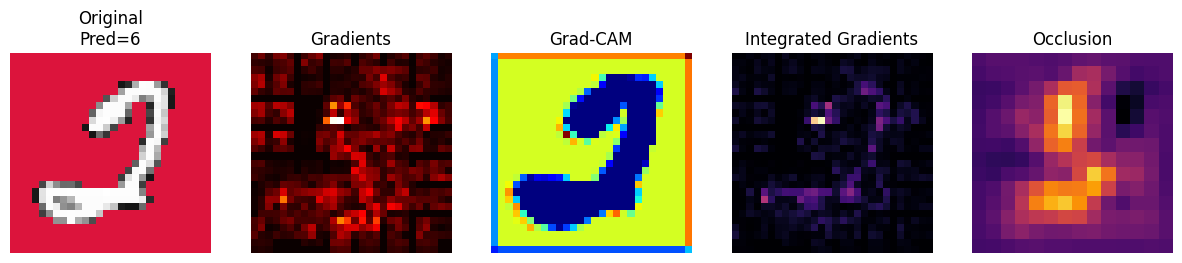

In [15]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Asumes que ya tienes: model, to_tensor, to_pil, device

challenge_dir = Path('../data/MNIST/challenge')
image_files = list(challenge_dir.glob('*.png'))

def show_saliency_maps(model, img_path):
    model.eval()
    img = to_tensor(Image.open(img_path)).unsqueeze(0).to(device)
    img.requires_grad_()

    output = model(img)
    pred_class = output.argmax(dim=1).item()
    true_class = int(img_path.stem[-1])
    print(f"{img_path.name}: Pred={pred_class}, Label={true_class}")

    # --- 1️⃣ Gradient Saliency Map ---
    model.zero_grad()
    score = output[0, pred_class]
    score.backward()

    saliency = img.grad.abs().squeeze().cpu().numpy()
    saliency = saliency.max(axis=0)  # canal máximo
    saliency /= saliency.max()

    # --- 2️⃣ Grad-CAM (versión compatible con backward hooks clásicos) ---
    target_layer = model.conv1

    # Limpieza completa de hooks previos
    if hasattr(target_layer, "_backward_hooks"):
        target_layer._backward_hooks.clear()
    if hasattr(target_layer, "_forward_hooks"):
        target_layer._forward_hooks.clear()
    if hasattr(target_layer, "_forward_pre_hooks"):
        target_layer._forward_pre_hooks.clear()

    act = None
    grad = None

    def forward_hook(module, input, output):
        nonlocal act
        act = output.detach()

    def backward_hook(module, grad_input, grad_output):
        nonlocal grad
        grad = grad_output[0].detach()

    # Usar solo register_backward_hook (compatible con todos los PyTorch)
    h1 = target_layer.register_forward_hook(forward_hook)
    h2 = target_layer.register_backward_hook(backward_hook)

    # Forward + backward
    out = model(img)
    model.zero_grad()
    out[0, pred_class].backward()

    if grad is None or act is None:
        raise RuntimeError("Grad-CAM hooks did not capture gradients properly.")

    # Calcular Grad-CAM
    weights = grad.mean(dim=(2, 3), keepdim=True)
    cam = (weights * act).sum(dim=1, keepdim=True)
    cam = F.relu(cam)
    cam = F.interpolate(cam, size=(28, 28), mode='bilinear', align_corners=False)
    cam = cam.squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    h1.remove()
    h2.remove()

    # --- 3️⃣ Integrated Gradients (versión robusta) ---
    steps = 50
    baseline = torch.zeros_like(img)
    scaled_imgs = [baseline + (i / steps) * (img - baseline) for i in range(1, steps + 1)]

    grads = []
    for s_img in scaled_imgs:
        s_img = s_img.clone().detach().requires_grad_(True)
        output = model(s_img)
        score = output[0, pred_class]
        grad = torch.autograd.grad(outputs=score, inputs=s_img)[0]  # <- ESTA LÍNEA ES CLAVE
        grads.append(grad)

    avg_grads = torch.mean(torch.stack(grads), dim=0)
    ig = (img - baseline) * avg_grads
    ig = ig.abs().detach().squeeze().cpu().numpy().max(axis=0)
    ig = ig / (ig.max() + 1e-8)


    # --- 4️⃣ Occlusion Sensitivity ---
    window_size = 4  # píxeles por lado del bloque
    stride = 2       # desplazamiento del bloque
    baseline_value = 0.0  # color gris oscuro (como fondo de MNIST)

    _, _, H, W = img.shape
    heatmap = torch.zeros((H, W))

    with torch.no_grad():
        base_score = F.softmax(model(img), dim=1)[0, pred_class].item()

    for i in range(0, H - window_size + 1, stride):
        for j in range(0, W - window_size + 1, stride):
            occluded = img.clone()
            occluded[:, :, i:i+window_size, j:j+window_size] = baseline_value
            with torch.no_grad():
                occl_score = F.softmax(model(occluded), dim=1)[0, pred_class].item()
            delta = base_score - occl_score
            heatmap[i:i+window_size, j:j+window_size] += delta

    heatmap = heatmap / heatmap.max()
    heatmap = heatmap.cpu().numpy()

    # Añadimos al plot
    fig, axs = plt.subplots(1, 5, figsize=(15, 4))
    axs[0].imshow(to_pil(img.squeeze().cpu())); axs[0].set_title(f"Original\nPred={pred_class}")
    axs[1].imshow(saliency, cmap='hot'); axs[1].set_title("Gradients")
    axs[2].imshow(cam, cmap='jet'); axs[2].set_title("Grad-CAM")
    axs[3].imshow(ig, cmap='magma'); axs[3].set_title("Integrated Gradients")
    axs[4].imshow(heatmap, cmap='inferno'); axs[4].set_title("Occlusion")
    for ax in axs: ax.axis('off')
    plt.show()


for img_path in image_files:
    show_saliency_maps(model, img_path)


step   0: target prob=0.0477
✅ Target class 5 achieved at step 2
0_label5.png: True=5, Adv Pred=5, Target=5, Pct Changed=0.3992


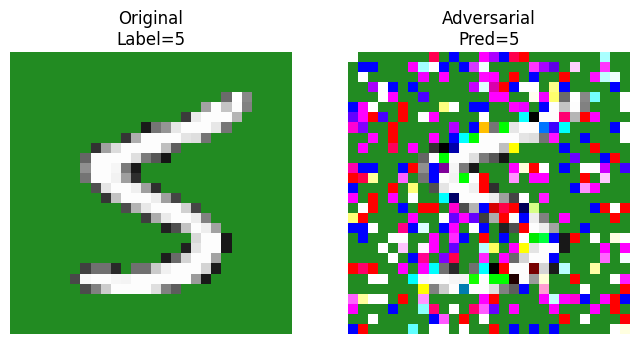

step   0: target prob=0.2589
step  10: target prob=0.2576
step  20: target prob=0.1103
step  30: target prob=0.2589
step  40: target prob=0.1016
step  50: target prob=0.1096
step  60: target prob=0.0463
step  70: target prob=0.0852
step  80: target prob=0.0048
✅ Target class 3 achieved at step 89
1_label3.png: True=3, Adv Pred=1, Target=3, Pct Changed=0.0000


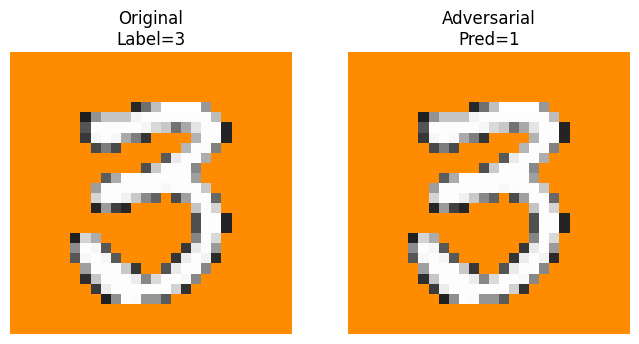

step   0: target prob=0.0751
step  10: target prob=0.0009
step  20: target prob=0.0002
step  30: target prob=0.0368
step  40: target prob=0.1481
step  50: target prob=0.0137
step  60: target prob=0.0025
step  70: target prob=0.0013
step  80: target prob=0.0166
step  90: target prob=0.1175
step 100: target prob=0.0063
step 110: target prob=0.0065
step 120: target prob=0.0636
step 130: target prob=0.0275
step 140: target prob=0.0017
step 150: target prob=0.0067
✅ Target class 3 achieved at step 154
2_label3.png: True=3, Adv Pred=1, Target=3, Pct Changed=0.0000


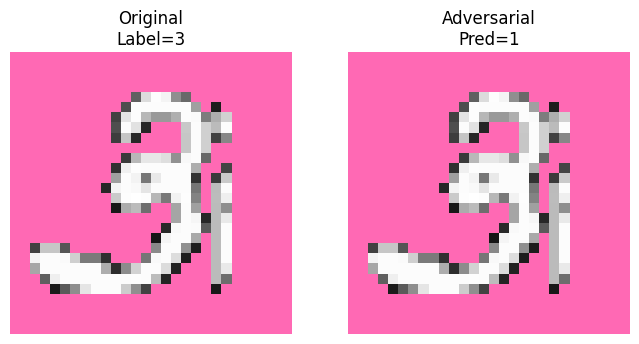

step   0: target prob=0.0030
step  10: target prob=0.0458
step  20: target prob=0.0072
step  30: target prob=0.0302
step  40: target prob=0.0291
step  50: target prob=0.0003
step  60: target prob=0.0006
step  70: target prob=0.0001
step  80: target prob=0.0040
step  90: target prob=0.0577
step 100: target prob=0.0099
step 110: target prob=0.0015
step 120: target prob=0.0156
step 130: target prob=0.0025
step 140: target prob=0.0105
step 150: target prob=0.0002
✅ Target class 7 achieved at step 156
3_label7.png: True=7, Adv Pred=7, Target=7, Pct Changed=0.3992


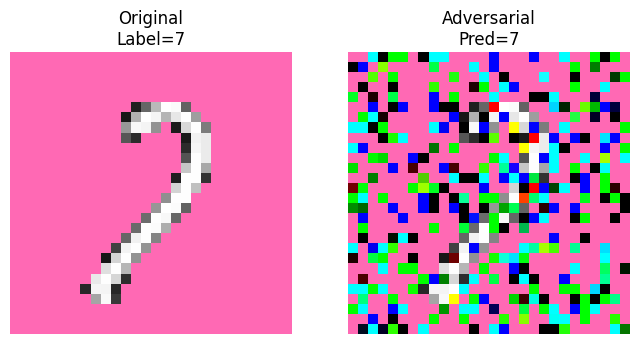

step   0: target prob=0.4328
✅ Target class 2 achieved at step 1
4_label2.png: True=2, Adv Pred=2, Target=2, Pct Changed=0.3992


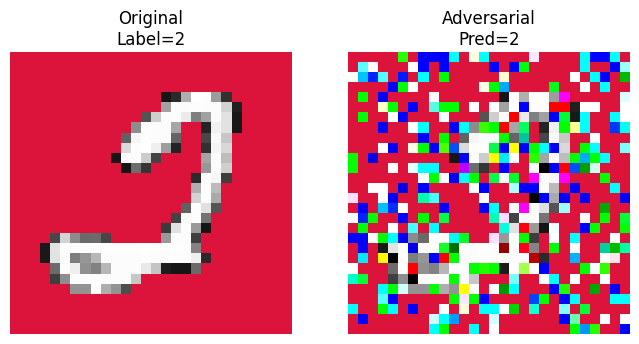

In [44]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
to_tensor, to_pil = transforms.ToTensor(), transforms.ToPILImage()
torch.manual_seed(42)

challenge_dir = Path('../data/MNIST/challenge')
out_dir = challenge_dir / 'edited'
out_dir.mkdir(parents=True, exist_ok=True)

def percent_pixels_changed(x0, x1, thresh=1/255):
    diff = (x0 - x1).abs()
    per_pos = diff.max(dim=1)[0]
    return float((per_pos > thresh).float().mean().item())

# --- NES-like black-box optimization ---
'''
def blackbox_optimize(model, x0, target, steps=200, sigma=1, alpha=0.7, n_dirs=40, pct=0.4):
    """
    Black-box optimization: NES-like attack that does NOT rely on model gradients.
    Works even in saturated regions.
    """
    model.eval()
    # Ensure 4D tensor [1,C,H,W]
    if x0.dim() == 3:
        x = x0.unsqueeze(0).clone().detach().to(device)
    else:
        x = x0.clone().detach().to(device)

    x0 = x.clone().detach()
    best_x = x.clone()
    best_score = F.softmax(model(x), dim=1)[0, target].item()

    _, C, H, W = x.shape
    k = int(pct * H * W)

    for step in range(steps):
        # sample random directions (n_dirs,C,H,W)
        noises = torch.randn((n_dirs, C, H, W), device=device)
        scores = torch.zeros(n_dirs, device=device)

        # evaluate each perturbation
        for i in range(n_dirs):
            x_pert = (x + sigma * noises[i:i+1]).clamp(0, 1)  # keep shape [1,C,H,W]
            s = F.softmax(model(x_pert), dim=1)[0, target].item()
            scores[i] = s

        # NES estimated gradient
        est_grad = (scores.view(n_dirs, 1, 1, 1) * noises).mean(dim=0)
        est_grad = est_grad / (est_grad.abs().mean() + 1e-8)

        # update
        x_new = (x + alpha * est_grad).clamp(0, 1)

        # --- L0 projection (keep top-k pixels with largest change) ---
        diff = (x_new - x0).abs().sum(1, keepdim=True)  # shape [1,1,H,W]
        flat = diff.view(-1)
        if k < flat.numel():
            th = torch.topk(flat, k).values.min()
            mask = (diff >= th).float()  # [1,1,H,W]
        else:
            mask = torch.ones_like(diff)

        mask = mask.repeat(1, C, 1, 1)  # -> [1,C,H,W]
        x_new = x0 * (1 - mask) + x_new * mask

        # evaluate
        score_new = F.softmax(model(x_new), dim=1)[0, target].item()
        if score_new > best_score:
            best_score = score_new
            best_x = x_new.clone()

        x = x_new.clone().detach()

        if step % 10 == 0:
            print(f"step {step:3d}: target prob={score_new:.4f}")

        # early stop if success
        if model(x).argmax(1).item() == target:
            print(f"✅ Target class {target} achieved at step {step}")
            break

    return best_x.squeeze(0).cpu(), best_score
'''

def blackbox_optimize_simple(model, x0, target, steps=200, sigma=1.0, alpha=2.0, pct=0.4):
    """
    Versión simplificada de optimización black-box usando UN solo ruido por paso.
    Se estima la dirección útil con la diferencia de la probabilidad objetivo
    entre x+sigma*noise y x-sigma*noise (aprox. derivada direccional).
    Mantiene la proyección L0 (conserva solo top-k píxeles cambiados).
    """
    model.eval()

    # normalizar forma a [1,C,H,W]
    if x0.dim() == 3:
        x = x0.unsqueeze(0).clone().detach().to(device)
    else:
        x = x0.clone().detach().to(device)

    x0 = x.clone().detach()
    best_x = x.clone()
    best_score = F.softmax(model(x), dim=1)[0, target].item()

    _, C, H, W = x.shape
    k = int(pct * H * W)

    for step in range(steps):
        # un solo ruido (misma forma que x)
        noise = torch.randn_like(x, device=device)

        # evaluamos +noise y -noise (simetría para mejor estimación)
        x_plus = (x + sigma * noise).clamp(0, 1)
        x_minus = (x - sigma * noise).clamp(0, 1)

        s_plus = F.softmax(model(x_plus), dim=1)[0, target].item()
        s_minus = F.softmax(model(x_minus), dim=1)[0, target].item()

        # estimador direccional: (s_plus - s_minus) escala al ruido
        # dividimos por 2 para la diferencia central; la normalización evita escalas raros
        est_grad = ((s_plus - s_minus) / 2.0) * noise
        est_grad = est_grad / (est_grad.abs().mean() + 1e-8)

        # paso de actualización
        x_new = (x + alpha * est_grad).clamp(0, 1)

        # --- Proyección L0: conservar solo los k píxeles con mayor cambio ---
        diff = (x_new - x0).abs().sum(1, keepdim=True)  # [1,1,H,W]
        flat = diff.view(-1)
        if k < flat.numel():
            th = torch.topk(flat, k).values.min()
            mask = (diff >= th).float()
        else:
            mask = torch.ones_like(diff)

        mask = mask.repeat(1, C, 1, 1)  # [1,C,H,W]
        x_new = x0 * (1 - mask) + x_new * mask

        # evaluar y guardar mejor resultado
        score_new = F.softmax(model(x_new), dim=1)[0, target].item()
        if score_new > best_score:
            best_score = score_new
            best_x = x_new.clone()

        x = x_new.clone().detach()

        if step % 10 == 0:
            print(f"step {step:3d}: target prob={score_new:.4f}")

        # early stop si la predicción ya es la clase objetivo
        if model(x).argmax(1).item() == target:
            print(f"✅ Target class {target} achieved at step {step}")
            break

    return best_x.squeeze(0).cpu(), best_score


for img_path in challenge_dir.glob('*.png'):
    img = to_tensor(Image.open(img_path)).unsqueeze(0).to(device)
    true_label = int(img_path.stem[-1])
    # target_label = (true_label + 1) % 10  # objetivo arbitrario diferente

    adv_img, final_score = blackbox_optimize_simple(model, img, true_label, steps=200, pct=0.4)
    adv_pred = model(adv_img.unsqueeze(0).to(device)).argmax(dim=1).item()
    pct_changed = percent_pixels_changed(img, adv_img.unsqueeze(0).to(device))

    print(f"{img_path.name}: True={true_label}, Adv Pred={adv_pred}, Target={true_label}, Pct Changed={pct_changed:.4f}")
    # Guardar imagen adversarial
    adv_pil = to_pil(adv_img.squeeze())
    adv_pil.save(out_dir / img_path.name)

    # Mostrar comparación
    fig, axs = plt.subplots(1, 2, figsize=(8,4))
    axs[0].imshow(to_pil(img.squeeze().cpu())); axs[0].set_title(f"Original\nLabel={true_label}")
    axs[1].imshow(adv_pil); axs[1].set_title(f"Adversarial\nPred={adv_pred}")
    for ax in axs: ax.axis('off')
    plt.show()

---
## Check if you have passed the challenge 

In [45]:
# Check percentage of editing an image
def calculate_edit_percentage(original_img, edited_img):
    original_pixels = original_img.load()
    edited_pixels = edited_img.load()
    width, height = original_img.size
    total_pixels = width * height
    changed_pixels = 0

    for x in range(width):
        for y in range(height):
            if original_pixels[x, y] != edited_pixels[x, y]:
                changed_pixels += 1

    return (changed_pixels / total_pixels) * 100

In [46]:
# Create edited directory
edited_dir = challenge_dir / 'edited'

# Load edited images, check that they are predicted correctly and calculate edit percentages
for original_img_file, edited_img_file in zip(challenge_dir.glob('*.png'), edited_dir.glob('*.png')):
    original_img = Image.open(original_img_file)
    edited_img = Image.open(edited_img_file)
    # Convert the edited image to RGB if it's not
    if edited_img.mode != 'RGB':
        edited_img = edited_img.convert('RGB')

    # Check prediction
    img_tensor = to_tensor(edited_img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_tensor)
        pred = output.argmax(dim=1).item()
    
    print(f'Edited {edited_img_file.name}: Pred: {pred}, Label: {original_img_file.stem[-1]}, correct: {pred == int(original_img_file.stem[-1])}')

    # Calculate edit percentage
    edit_percentage = calculate_edit_percentage(original_img, edited_img)
    print(f'Edit Percentage: {edit_percentage:.2f}%')


Edited 0_label5.png: Pred: 5, Label: 5, correct: True
Edit Percentage: 39.92%
Edited 1_label3.png: Pred: 1, Label: 3, correct: False
Edit Percentage: 0.00%
Edited 2_label3.png: Pred: 1, Label: 3, correct: False
Edit Percentage: 0.00%
Edited 3_label7.png: Pred: 7, Label: 7, correct: True
Edit Percentage: 39.92%
Edited 4_label2.png: Pred: 2, Label: 2, correct: True
Edit Percentage: 39.92%
